In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten


In [2]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

maxlen = 200
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


C:\Users\chaus\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Training data shape: (25000, 200)
Testing data shape: (25000, 200)


In [4]:

model = Sequential([
    Embedding(input_dim=10000, output_dim=32, input_length=maxlen),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])



C:\Users\chaus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)



Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7240 - loss: 0.5093 - val_accuracy: 0.8506 - val_loss: 0.3472
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9347 - loss: 0.1751 - val_accuracy: 0.8562 - val_loss: 0.3482
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9902 - loss: 0.0403 - val_accuracy: 0.8498 - val_loss: 0.4457
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9991 - loss: 0.0055 - val_accuracy: 0.8534 - val_loss: 0.5650
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 0.8528 - val_loss: 0.6015
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 1.0000 - loss: 5.0829e-04 - val_accuracy: 0.8520 - val_loss: 0.6386
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 1.0000 - loss: 1.9176e-04 - val_accuracy: 0.8532 - val_loss: 0.6605
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 1.0000 - loss: 1.2600e-0

In [7]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_accuracy)

predictions = model.predict(x_test[:5])




782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8510 - loss: 0.7027
Test Accuracy: 0.8509600162506104
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


In [8]:
print("\nSample Predictions:")
for i in range(5):
    pred = predictions[i][0]
    actual = y_test[i]
    predicted_label = "Positive" if pred > 0.5 else "Negative"
    actual_label = "Positive" if actual == 1 else "Negative"
    print(f"Review {i+1}: Predicted = {predicted_label}, Actual = {actual_label}")




Sample Predictions:
Review 1: Predicted = Negative, Actual = Negative
Review 2: Predicted = Positive, Actual = Positive
Review 3: Predicted = Positive, Actual = Positive
Review 4: Predicted = Positive, Actual = Negative
Review 5: Predicted = Positive, Actual = Positive


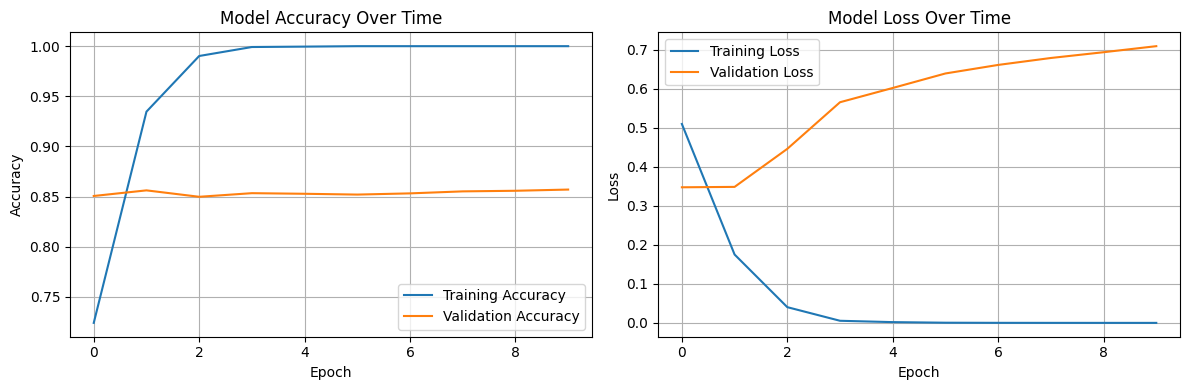

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()